In [67]:
from google.colab import drive
drive.mount('drive')

Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).


In [89]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [69]:
df = pd.read_csv('/content/drive/MyDrive/cumulative.csv')
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [70]:
df.tail()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9563,9564,10156110,K07989.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,1,...,-225.0,4.385,0.054,-0.216,1.193,0.410,-0.137,297.00977,47.121021,14.826


In [71]:
df.columns

Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

In [72]:
df = df.drop(columns=['rowid'])

In [73]:
df = df.drop(columns=['kepid'])

In [74]:
df = df.drop(columns=['kepoi_name'])

In [75]:
df = df.drop(columns=['kepler_name'])

In [76]:
df['koi_disposition'].unique()

array(['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE'], dtype=object)

In [77]:
df['koi_pdisposition'].unique()

array(['CANDIDATE', 'FALSE POSITIVE'], dtype=object)

In [78]:
disposition_map = {
    'FALSE POSITIVE': 0,
    'CONFIRMED': 2,
    'CANDIDATE': 1
}
df['koi_disposition'] = df['koi_disposition'].map(disposition_map)

In [79]:
df['koi_pdisposition'].value_counts()

,count
koi_pdisposition,
FALSE POSITIVE,5068
CANDIDATE,4496


In [80]:
disposition_map = {
    'FALSE POSITIVE': 0,
    'CANDIDATE': 1
}
df['koi_pdisposition'] = df['koi_pdisposition'].map(disposition_map)

In [81]:
print(df.isnull().sum())

koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff             363
koi_steff_err1        468
koi_steff_err2        483
koi_slogg             363
koi_slogg_er

In [82]:
X = df[['koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_duration', 'koi_depth', 'koi_prad']]

In [83]:
Y = df['koi_disposition']

In [84]:
len(X), len(Y)

(9564, 9564)

In [85]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [86]:
Xtrain.head()

,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_duration,koi_depth,koi_prad
8117,0.000,0,1,0,0,0.651732,1.400000e-07,-1.400000e-07,131.751463,2.4602,20524.0,71.90
5245,0.000,0,1,0,0,0.948952,6.240000e-07,-6.240000e-07,132.468516,4.3809,458460.0,115.31
5865,0.908,0,0,0,0,4.644901,3.836000e-05,-3.836000e-05,133.674360,2.4560,106.4,0.76
4050,NaN,0,0,0,0,309.255810,1.495000e-02,-1.495000e-02,136.224800,10.7200,421.4,2.18
5130,0.000,1,0,0,0,0.916327,3.810000e-07,-3.810000e-07,131.809050,3.1427,96384.0,50.70


In [87]:
Ytest.head()

,koi_disposition
9004,0
5028,0
1142,0
1355,1
8740,0


In [88]:
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

In [90]:
model = RandomForestClassifier(random_state=42)
model.fit(Xtrain_scaled, Ytrain)

RandomForestClassifier(random_state=42)

In [91]:
model.predict(Xtest_scaled)

array([0, 0, 0, ..., 2, 0, 0])

In [92]:
print(f"Accuracy: {accuracy_score(Ytest, model.predict(Xtest_scaled))}")

Accuracy: 0.882906429691584


In [93]:
print("confusion matrix")
print(confusion_matrix(Ytest, model.predict(Xtest_scaled)))

confusion matrix
[[990  18   0]
 [ 10 335 106]
 [ 10  80 364]]


In [98]:
print(classification_report(Ytest, model.predict(Xtest_scaled)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1008
           1       0.77      0.74      0.76       451
           2       0.77      0.80      0.79       454

    accuracy                           0.88      1913
   macro avg       0.84      0.84      0.84      1913
weighted avg       0.88      0.88      0.88      1913



In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Features')

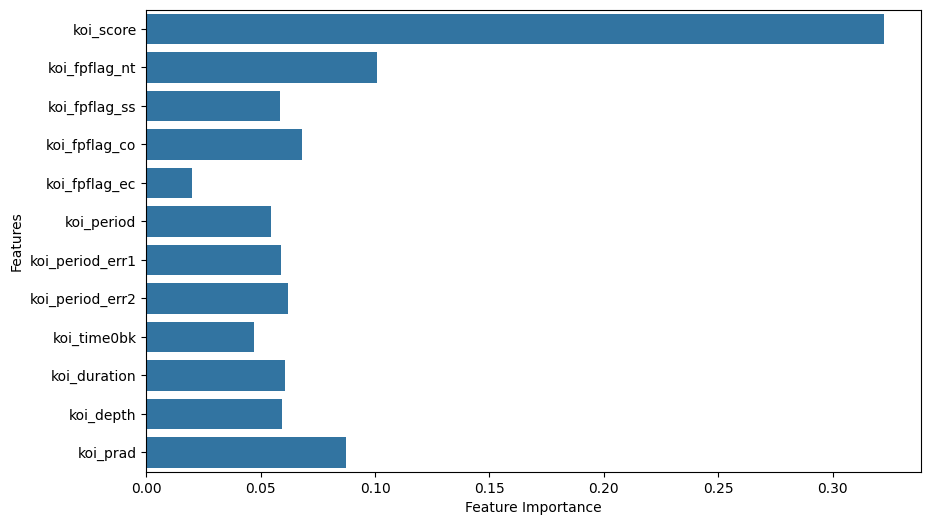

In [96]:
feature_importances = model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Features')

Text(95.72222222222221, 0.5, 'Actual')

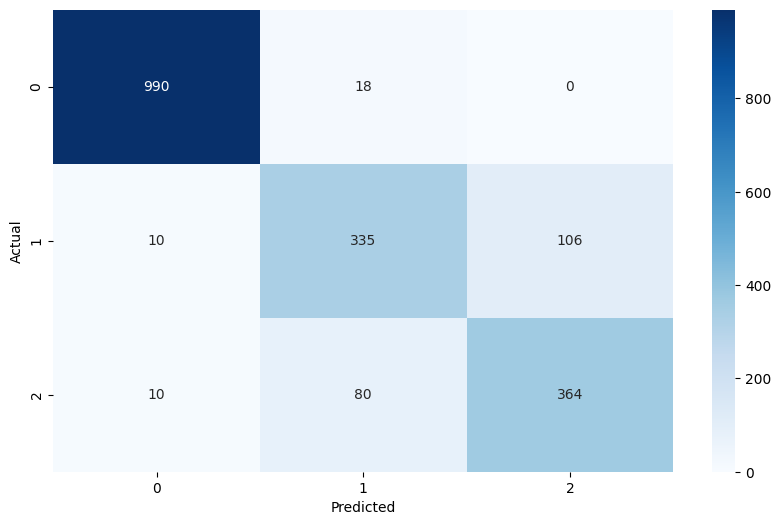

In [97]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(Ytest, model.predict(Xtest_scaled)), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')